In [2]:
import numpy as np
import math as math
import pandas as pd

from numba import njit

from scipy.linalg import hadamard
from numpy import linalg as la

import time
from time import strftime

rng = np.random.default_rng()

Data Gen

In [3]:
# 2^10 rows and 2^4 columns
rows = 2**10
c = 2**6
params = (rng.normal(loc=0.0, scale=5, size=(rows, c)))
weights = rng.normal(loc=0.0, scale=3, size=(c,)) + rng.normal(loc=3, scale = 1, size=(c,)) + rng.normal(loc=-3, scale=0.5, size=(c,))
# print(weights)

y = params @ weights + rng.normal(loc=0.0, scale=0.5, size=(rows,))

data = np.hstack((params, y.reshape(-1, 1)))
pd.DataFrame(data).to_csv(f'{rows}x{c}.csv', header=False, index=False)

In [4]:
# Fischer Info
def fisher_info(X, sigma2):
    return (X.T @ X) / sigma2

print(np.linalg.det(fisher_info(params, 0.5)))


3.746124579084803e+300


In [4]:
# OLS
beta_h = np.linalg.inv(params.T @ params) @ params.T @ y

# R^2
mu = np.mean(y)
tss = np.sum((y - mu)**2)
yhat = params @ beta_h
ss = np.sum((y - yhat)**2)
r2 = 1 - (ss/tss)

print("R^2: ", r2)

R^2:  0.9999858111594696


In [6]:
print(hadamard(4))
print(la.matrix_rank(params))

[[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]
64


Hadamard Transform

In [95]:
r = 16

# Random D matrix
diags = np.random.choice([-1, 1], size=(c,))
D = np.diag(diags)
# print(D.shape)

# 16*16 Hadamard Matrix
H_16 = hadamard(c)/np.sqrt(c)
print(la.det(H_16))
# print(H_16.shape)

# Randomly sampling r columns from d*d I
P = rng.choice(np.eye(c), size=(r)).T
# print(P.shape)

R = np.sqrt(c/r) * D @ H_16 @ P

X_r = params @ R
beta_R = (weights.T @ P).T

1.0000000000000013


Tests on Transformed Matrix

In [8]:
print(np.linalg.det(fisher_info(X_r, 0.5)))
print(np.linalg.matrix_rank(X_r))

-1.0033487478679802e+45
13


Transform OG dataset and Response Vector (CAN'T BE DONE W/ COLUMN SELECTION)

In [96]:
yr = X_r @ beta_R + rng.normal(loc=0.0, scale=0.5, size=(rows,))
beta_r = la.inv(X_r.T @ X_r) @ X_r.T @ yr
yhat_r = X_r @ beta_r
ss_r = np.sum((yr - yhat_r)**2)
tss_r = np.sum((yr - np.mean(yr))**2)
r2_r = 1 - (ss_r/tss_r)
print("R^2 (RHT): ", r2_r)


R^2 (RHT):  0.9978934965272186


In [6]:
beta_2 = la.inv(X_r.T @ X_r) @ X_r.T @ y
yhat_r = X_r @ beta_2

In [264]:
A = np.array([[1, 2, 3], [2, 3, 3]])
B = np.array([[0, 1], [1, 0], [1, 1]])

print(A.shape)
print(A @ B)

(2, 3)
[[5 4]
 [6 5]]


Let's try Rows

- y.T = beta.T @ X.T
- I can project y, if I can project X.T

In [7]:
XT = params.T
rt, ct = (XT.shape)

r_n = 2**10

# Random D matrix
diags = np.random.choice([-1, 1], size=(ct,))
D = np.diag(diags)
# print(D.shape)

# 16*16 Hadamard Matrix
H_16 = hadamard(ct)/np.sqrt(ct)
# print(la.det(H_16))
# print(H_16.shape)

# Randomly sampling r columns from d*d I
P = rng.choice(np.eye(ct), size=(r_n)).T
# print(P.shape)

R = np.sqrt(ct/r_n) * D @ H_16 @ P

X_n = (XT @ R).T
y_n = (weights.T @ XT @ R).T + rng.normal(loc=0.0, scale=0.5, size=(r_n,))

In [9]:
i = fisher_info(X_n, 0.5)
print(la.det(i))

2.138068325649868e+299


In [8]:
# OLS and Stuff
beta_n = la.inv(X_n.T @ X_n) @ X_n.T @ y_n
yhat_n = X_n @ beta_n
ss_n = np.sum((y_n - yhat_n)**2)
tss_n = np.sum((y_n - np.mean(y_n))**2)
r2_n = 1 - (ss_n/tss_n)
print("R^2 (NRHT): ", r2_n)

R^2 (NRHT):  0.9999888370397413


In [15]:
import scipy.linalg

@njit
def shrt_run(r_n):
    XT = params.T
    rt, ct = (XT.shape)

    # Random D matrix
    diags = np.random.choice([-1, 1], size=(ct,))
    D = np.diag(diags)
    # print(D.shape)

    # 16*16 Hadamard Matrix
    H_16 = scipy.linalg.hadamard(ct)/np.sqrt(ct)
    # print(la.det(H_16))
    # print(H_16.shape)

    # Randomly sampling r columns from d*d I
    P = rng.choice(np.eye(ct), size=(r_n)).T
    # print(P.shape)

    R = np.sqrt(ct/r_n) * D @ H_16 @ P

    X_n = (params.T @ R).T
    y_n = (weights.T @ params.T @ R).T + rng.normal(loc=0.0, scale=0.5, size=(r_n,))
    
    i = fisher_info(X_n, 0.5)
    
    # OLS and Stuff
    beta_n = la.inv(X_n.T @ X_n) @ X_n.T @ y_n
    yhat_n = X_n @ beta_n
    ss_n = np.sum((y_n - yhat_n)**2)
    tss_n = np.sum((y_n - np.mean(y_n))**2)
    r2_n = 1 - (ss_n/tss_n)
    
    return la.det(i), r2_n

R2 Histogram

In [11]:
import matplotlib.pyplot as plt

In [16]:
# 100 runs of NHRT
r_2s = []
infos = []

r_test = 60

for i in range(100):
    det_i, r2_n = shrt_run(r_test)
    infos.append(det_i)
    r_2s.append(r2_n)

plt.title(f'R^2 for 100 runs with r_n = {r_test}')
plt.hist(r_2s)
plt.show()

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1mUntyped global name 'fisher_info':[0m [1m[1mCannot determine Numba type of <class 'function'>[0m
[1m
File "..\..\..\..\..\..\AppData\Local\Temp\ipykernel_24808\3991573746.py", line 27:[0m
[1m<source missing, REPL/exec in use?>[0m
[0m

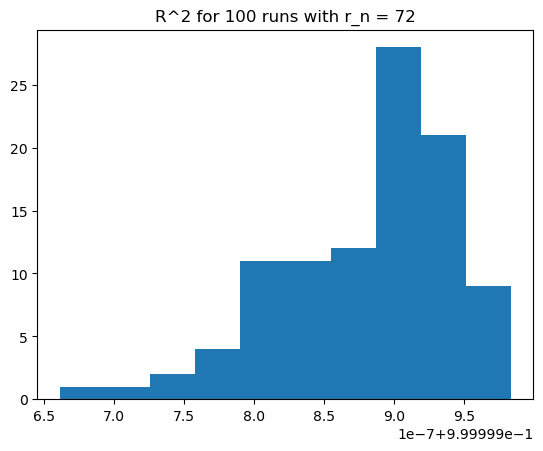

In [97]:
# 100 runs of NHRT
r_2s = []
infos = []

r_test = 72

for i in range(100):
    det_i, r2_n = shrt_run(r_test)
    infos.append(det_i)
    r_2s.append(r2_n)

plt.title(f'R^2 for 100 runs with r_n = {r_test}')
plt.hist(r_2s, )
plt.show()

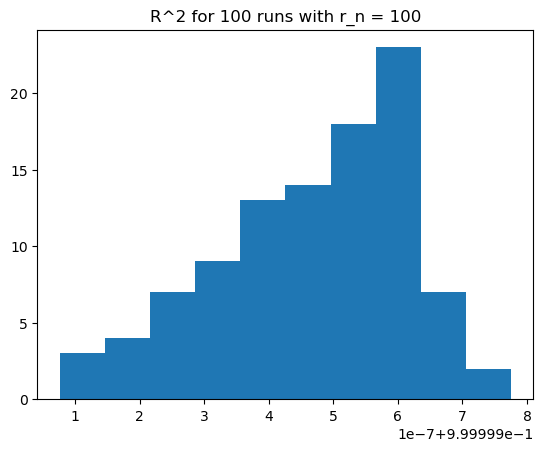

0.9999997751285119 0.9999994664086447


In [20]:
# 100 runs of NHRT
r_2s = []
infos = []

r_test = 100

for i in range(100):
    det_i, r2_n = shrt_run(r_test)
    infos.append(det_i)
    r_2s.append(r2_n)

plt.title(f'R^2 for 100 runs with r_n = {r_test}')
plt.hist(r_2s)
plt.show()

print(max(r_2s), np.mean(r_2s))

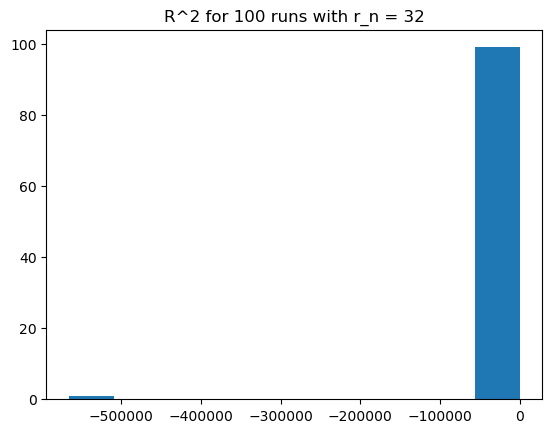

-5.879298648976009 -6289.617090711994


In [17]:
# 100 runs of NHRT
r_2s = []
infos = []

r_test = 32

for i in range(100):
    det_i, r2_n = shrt_run(r_test)
    infos.append(det_i)
    r_2s.append(r2_n)

plt.title(f'R^2 for 100 runs with r_n = {r_test}')
plt.hist(r_2s)
plt.show()

print(max(r_2s), np.mean(r_2s))

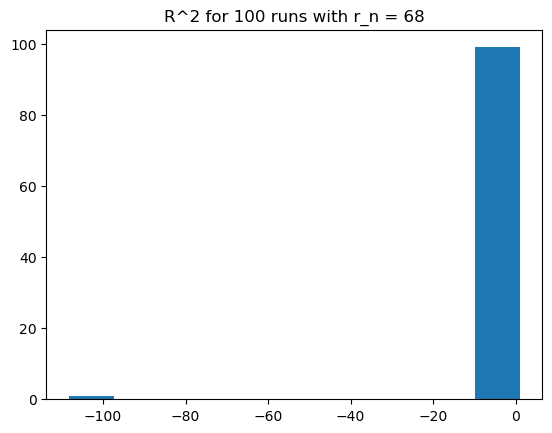

0.9999999959890231 -0.19680327698185845


In [18]:
# 100 runs of NHRT
r_2s = []
infos = []

r_test = 68

for i in range(100):
    det_i, r2_n = shrt_run(r_test)
    infos.append(det_i)
    r_2s.append(r2_n)

plt.title(f'R^2 for 100 runs with r_n = {r_test}')
plt.hist(r_2s)
plt.show()

print(max(r_2s), np.mean(r_2s))

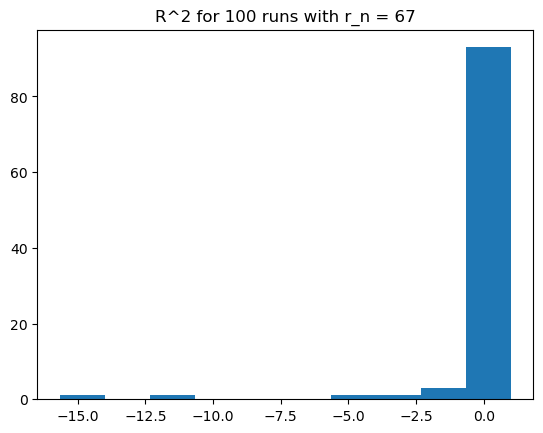

0.9999999995387747 0.5206248098233323


In [24]:
# 100 runs of NHRT
r_2s = []
infos = []

r_test = 67

for i in range(100):
    det_i, r2_n = shrt_run(r_test)
    infos.append(det_i)
    r_2s.append(r2_n)

plt.title(f'R^2 for 100 runs with r_n = {r_test}')
plt.hist(r_2s)
plt.show()

print(max(r_2s), np.mean(r_2s))